# SimCLR and Supervised Contrastive Learning
### Rust / Corrosion Detection — Representation Learning Pipeline

**Goal:** Learn a feature encoder that separates CORROSION from NOCORROSION.

**Dataset structure:**
- `train/` — CORROSION + NOCORROSION (labeled, used for SupCon + eval)
- `simclr_unlabeled/images/` — all other images (unlabeled, used for SimCLR pretraining only)
- `test/` — CORROSION + NOCORROSION (evaluation)
- `unknown_val/` — OOD textures (rejection evaluation)

**Pipeline:**
- **Section 1** — Setup & Data
- **Section 2** — SimCLR (self-supervised pretraining on all data)
- **Section 3** — SupCon (supervised contrastive on binary labeled data)
- **Section 4** — Two-Stage: SimCLR backbone → SupCon fine-tune
- **Section 5** — Final Comparison
- **Section 6** — Rejection Thresholding

## Section 1 — Setup & Data

In [1]:
import random
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms, models

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Global config

SEED        = 42
IMG_SIZE    = 224
NUM_WORKERS = 0

DATA_ROOT      = Path("rust_dataset_2")
TRAIN_DIR      = DATA_ROOT / "train"
VAL_DIR        = DATA_ROOT / "test"
UNLABELED_DIR  = DATA_ROOT / "simclr_unlabeled"
UNKNOWN_DIR    = DATA_ROOT / "unknown_val"

# SimCLR — self-supervised, trains on all data
SIMCLR_PROJ_DIM = 128
SIMCLR_TEMP     = 0.5
SIMCLR_LR       = 1e-3
SIMCLR_EPOCHS   = 50
SIMCLR_BATCH    = 128

# SupCon — supervised, trains on CORROSION + NOCORROSION only
SUPCON_PROJ_DIM = 128
SUPCON_TEMP     = 0.07
SUPCON_LR       = 1e-4
SUPCON_EPOCHS   = 50
SUPCON_BATCH    = 32

# ImageFolder sorts alphabetically: CORROSION=0, NOCORROSION=1
CORROSION_IDX = 0

In [3]:
# Device setup

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using Apple MPS")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using CUDA")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

print("Device:", DEVICE)

Using Apple MPS
Device: mps


In [4]:
# Reproducibility

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print("Seed set.")

Seed set.


In [5]:
# Transforms

class TwoCropTransform:
    # returns two independently augmented views of the same image
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return self.transform(x), self.transform(x)


# strong augmentation for SimCLR
simclr_transform = TwoCropTransform(transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=9, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
]))

# mild augmentation for SupCon
supcon_transform = TwoCropTransform(transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
]))

# standard single-crop for feature extraction / eval
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

print("Transforms ready.")


Transforms ready.


In [6]:
# Datasets and DataLoaders

# SimCLR: train on all available images (labeled + unlabeled)
train_ds_simclr  = datasets.ImageFolder(TRAIN_DIR,     transform=simclr_transform)
unlabeled_ds     = datasets.ImageFolder(UNLABELED_DIR, transform=simclr_transform)
all_ds_simclr    = ConcatDataset([train_ds_simclr, unlabeled_ds])
train_dl_simclr  = DataLoader(all_ds_simclr, batch_size=SIMCLR_BATCH,
                               shuffle=True, num_workers=NUM_WORKERS, drop_last=True)

# SupCon: train on CORROSION + NOCORROSION only
train_ds_twocrop = datasets.ImageFolder(TRAIN_DIR, transform=supcon_transform)
train_dl_supcon  = DataLoader(train_ds_twocrop, batch_size=SUPCON_BATCH,
                               shuffle=True, num_workers=NUM_WORKERS, drop_last=True)

# single-crop for feature extraction / evaluation
train_ds_eval = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)
val_ds_eval   = datasets.ImageFolder(VAL_DIR,   transform=eval_transform)
train_dl_eval = DataLoader(train_ds_eval, batch_size=64, shuffle=False,
                            num_workers=NUM_WORKERS)
val_dl_eval   = DataLoader(val_ds_eval,   batch_size=64, shuffle=False,
                            num_workers=NUM_WORKERS)

# unknown_val for rejection evaluation
unknown_ds = datasets.ImageFolder(UNKNOWN_DIR, transform=eval_transform)
unknown_dl = DataLoader(unknown_ds, batch_size=64, shuffle=False,
                         num_workers=NUM_WORKERS)

CLASS_NAMES = train_ds_eval.classes
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print(f"SimCLR train samples : {len(all_ds_simclr)}")
print(f"SupCon train samples : {len(train_ds_twocrop)}")
print(f"Val samples          : {len(val_ds_eval)}")
print(f"Unknown samples      : {len(unknown_ds)}")


Classes: ['CORROSION', 'NOCORROSION']
SimCLR train samples : 2432
SupCon train samples : 1218
Val samples          : 277
Unknown samples      : 173


## Section 2 — SimCLR (Self-Supervised Pretraining)

- trains on all images including unlabeled — no labels used
- two augmented views of each image are pushed together, all other pairs pushed apart
- NT-Xent loss with temperature scaling
- after training: extract backbone features and evaluate with a linear probe

In [7]:
# SimCLR model — ResNet18 backbone + 2-layer MLP projector

class SimCLR(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder   = nn.Sequential(*list(base.children())[:-1])  # [B, 512, 1, 1]
        self.feat_dim  = base.fc.in_features  # 512
        self.projector = nn.Sequential(
            nn.Linear(self.feat_dim, self.feat_dim),
            nn.ReLU(),
            nn.Linear(self.feat_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)   # [B, 512]
        z = self.projector(h)                          # [B, proj_dim]
        return h, F.normalize(z, dim=1)

In [8]:
# NT-Xent loss (SimCLR loss)
# positives = augmented pair of the same image
# negatives = all other images in the batch

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temp = temperature

    def forward(self, z1, z2):
        N   = z1.size(0)
        z   = torch.cat([z1, z2], dim=0)                    # [2N, D]
        sim = torch.mm(z, z.T) / self.temp                  # [2N, 2N]

        logits_max, _ = torch.max(sim, dim=1, keepdim=True)
        sim = sim - logits_max.detach()

        pos  = torch.cat([torch.diag(sim, N), torch.diag(sim, -N)])  # [2N]
        mask = ~torch.eye(2 * N, dtype=torch.bool, device=z.device)
        neg  = sim[mask].view(2 * N, -1)                    # [2N, 2N-1]

        logits = torch.cat([pos.unsqueeze(1), neg], dim=1)
        labels = torch.zeros(2 * N, dtype=torch.long, device=z.device)
        return F.cross_entropy(logits, labels)


In [9]:
# SimCLR training — one epoch

def train_simclr_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for (view1, view2), _ in dataloader:   # labels ignored
        view1 = view1.to(device)
        view2 = view2.to(device)

        optimizer.zero_grad()
        _, z1 = model(view1)
        _, z2 = model(view2)
        loss  = criterion(z1, z2)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * view1.size(0)

    return running_loss / len(dataloader.dataset)

In [10]:
# SimCLR full training loop

def fit_simclr_model(model, dataloader, criterion, optimizer, device,
                     epochs=20, checkpoint_path=None):
    history    = {"train_loss": []}
    best_loss  = float("inf")
    best_state = None

    for epoch in range(epochs):
        loss = train_simclr_one_epoch(model, dataloader, criterion, optimizer, device)
        history["train_loss"].append(loss)

        print(f"Epoch {epoch+1:02d}/{epochs} | loss={loss:.4f}")

        if loss < best_loss:
            best_loss  = loss
            best_state = deepcopy(model.state_dict())
            if checkpoint_path:
                torch.save(best_state, checkpoint_path)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_loss

In [11]:
# train SimCLR

simclr_model     = SimCLR(proj_dim=SIMCLR_PROJ_DIM).to(DEVICE)
simclr_criterion = NTXentLoss(temperature=SIMCLR_TEMP)
simclr_optimizer = torch.optim.Adam(simclr_model.parameters(), lr=SIMCLR_LR)

simclr_model, simclr_history, simclr_best_loss = fit_simclr_model(
    simclr_model,
    train_dl_simclr,
    simclr_criterion,
    simclr_optimizer,
    DEVICE,
    epochs=SIMCLR_EPOCHS,
    checkpoint_path="simclr_best.pt",
)

print(f"\nBest SimCLR loss: {simclr_best_loss:.4f}")

Epoch 01/50 | loss=4.2443
Epoch 02/50 | loss=4.0277
Epoch 03/50 | loss=3.9829
Epoch 04/50 | loss=3.9553
Epoch 05/50 | loss=3.9296
Epoch 06/50 | loss=3.9200
Epoch 07/50 | loss=3.9157
Epoch 08/50 | loss=3.9039
Epoch 09/50 | loss=3.8960
Epoch 10/50 | loss=3.8907
Epoch 11/50 | loss=3.8962
Epoch 12/50 | loss=3.8865
Epoch 13/50 | loss=3.8750
Epoch 14/50 | loss=3.8633
Epoch 15/50 | loss=3.8710
Epoch 16/50 | loss=3.8583
Epoch 17/50 | loss=3.8503
Epoch 18/50 | loss=3.8469
Epoch 19/50 | loss=3.8545
Epoch 20/50 | loss=3.8437
Epoch 21/50 | loss=3.8482
Epoch 22/50 | loss=3.8392
Epoch 23/50 | loss=3.8339
Epoch 24/50 | loss=3.8319
Epoch 25/50 | loss=3.8406
Epoch 26/50 | loss=3.8356
Epoch 27/50 | loss=3.8265
Epoch 28/50 | loss=3.8243
Epoch 29/50 | loss=3.8191
Epoch 30/50 | loss=3.8181
Epoch 31/50 | loss=3.8170
Epoch 32/50 | loss=3.8184
Epoch 33/50 | loss=3.8168
Epoch 34/50 | loss=3.8197
Epoch 35/50 | loss=3.8191
Epoch 36/50 | loss=3.8159
Epoch 37/50 | loss=3.8092
Epoch 38/50 | loss=3.8043
Epoch 39/50 

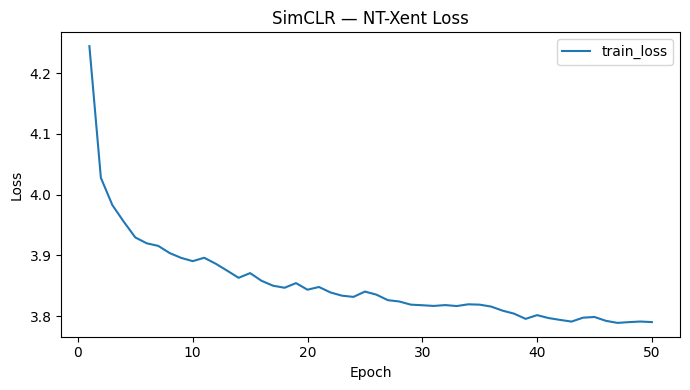

In [12]:
# plot SimCLR training loss

def plot_history(history, title="Training"):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(simclr_history, title="SimCLR — NT-Xent Loss")

In [13]:
# extract features from SimCLR backbone

def extract_embeddings(model, dataloader, device):
    model.eval()
    all_h, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            h, _   = model(images)
            all_h.append(h.cpu())
            all_labels.append(labels.cpu())
    Z = torch.cat(all_h,      dim=0)
    y = torch.cat(all_labels, dim=0)
    return Z, y

def l2_normalize_torch(Z, eps=1e-12):
    return Z / (Z.norm(dim=1, keepdim=True) + eps)

simclr_model.eval()
H_simclr_train, y_train = extract_embeddings(simclr_model, train_dl_eval, DEVICE)
H_simclr_val,   y_val   = extract_embeddings(simclr_model, val_dl_eval,   DEVICE)

H_simclr_train_l2 = l2_normalize_torch(H_simclr_train)
H_simclr_val_l2   = l2_normalize_torch(H_simclr_val)

print(f"SimCLR train features : {H_simclr_train.shape}")
print(f"SimCLR val   features : {H_simclr_val.shape}")

SimCLR train features : torch.Size([1218, 512])
SimCLR val   features : torch.Size([277, 512])


In [14]:
# linear probe — CORROSION vs NOCORROSION

def run_linear_probe(Z_train, y_train, Z_val, y_val, label=""):
    clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf.fit(Z_train.numpy(), y_train.numpy())
    train_acc = accuracy_score(y_train.numpy(), clf.predict(Z_train.numpy()))
    val_acc   = accuracy_score(y_val.numpy(),   clf.predict(Z_val.numpy()))
    print(f"{label:35s} | train={train_acc:.4f} | val={val_acc:.4f}")
    return train_acc, val_acc

print("SimCLR — Linear Probe (CORROSION vs NOCORROSION)")
print("-" * 65)
simclr_raw_train, simclr_raw_val = run_linear_probe(
    H_simclr_train,    y_train, H_simclr_val,    y_val, label="simclr_h_raw")
simclr_l2_train,  simclr_l2_val  = run_linear_probe(
    H_simclr_train_l2, y_train, H_simclr_val_l2, y_val, label="simclr_h_l2")

SimCLR — Linear Probe (CORROSION vs NOCORROSION)
-----------------------------------------------------------------
simclr_h_raw                        | train=0.9893 | val=0.9242
simclr_h_l2                         | train=0.9220 | val=0.9386


### short interpretation
- SimCLR is trained without labels on all available data
- the linear probe val accuracy shows how well the encoder separates CORROSION from NOCORROSION
- L2 normalisation often improves cosine-based classifiers

## Section 3 — Supervised Contrastive Learning (SupCon)

- trains on CORROSION + NOCORROSION only using class labels
- positives: all images of the same class in the batch
- negatives: all images of the opposite class in the batch
- evaluates both backbone features `h` (512-dim) and projection features `z` (128-dim)

In [15]:
# SupCon model — ResNet18 backbone + 2-layer MLP projector

class ResNet18SupCon(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.encoder   = nn.Sequential(*list(base.children())[:-1])
        self.feat_dim  = base.fc.in_features  # 512
        self.projector = nn.Sequential(
            nn.Linear(self.feat_dim, self.feat_dim),
            nn.ReLU(),
            nn.Linear(self.feat_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)
        z = self.projector(h)
        return h, F.normalize(z, dim=1)

In [16]:
class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temp = temperature

    def forward(self, features, labels):
        device = features.device
        B      = features.shape[0]

        f      = features.view(2 * B, -1)
        f      = F.normalize(f, dim=1)
        labels = labels.repeat(2)

        sim = torch.mm(f, f.T) / self.temp

        logits_max, _ = torch.max(sim, dim=1, keepdim=True)
        sim = sim - logits_max.detach()

        labels_eq = labels.unsqueeze(0) == labels.unsqueeze(1)
        self_mask = ~torch.eye(2 * B, dtype=torch.bool, device=device)
        pos_mask  = labels_eq & self_mask

        exp_sim  = torch.exp(sim) * self_mask
        log_prob = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)

        mean_log_prob = (pos_mask * log_prob).sum(dim=1) / (pos_mask.sum(dim=1) + 1e-12)
        return -mean_log_prob.mean()

In [17]:
# SupCon training — one epoch

def prepare_supcon_batch(view1, view2):
    return torch.stack([view1, view2], dim=1)   # [B, 2, C, H, W]

def train_supcon_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for (view1, view2), labels in dataloader:
        view1  = view1.to(device)
        view2  = view2.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        _, z1    = model(view1)
        _, z2    = model(view2)
        features = prepare_supcon_batch(z1, z2)
        loss     = criterion(features, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * view1.size(0)

    return running_loss / len(dataloader.dataset)

In [18]:
# SupCon full training loop with cosine annealing scheduler

def fit_supcon_model(model, dataloader, criterion, optimizer, device,
                     epochs=20, checkpoint_path=None):
    history    = {"train_loss": []}
    best_loss  = float("inf")
    best_state = None

    for epoch in range(epochs):
        loss = train_supcon_one_epoch(model, dataloader, criterion, optimizer, device)
        history["train_loss"].append(loss)

        print(f"Epoch {epoch+1:02d}/{epochs} | loss={loss:.4f}")

        if loss < best_loss:
            best_loss  = loss
            best_state = deepcopy(model.state_dict())
            if checkpoint_path:
                torch.save(best_state, checkpoint_path)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_loss


In [19]:
# train SupCon from scratch

supcon_model     = ResNet18SupCon(proj_dim=SUPCON_PROJ_DIM).to(DEVICE)
supcon_criterion = SupConLoss(temperature=SUPCON_TEMP)
supcon_optimizer = torch.optim.Adam(supcon_model.parameters(), lr=SUPCON_LR)

supcon_model, supcon_history, supcon_best_loss = fit_supcon_model(
    supcon_model,
    train_dl_supcon,
    supcon_criterion,
    supcon_optimizer,
    DEVICE,
    epochs=SUPCON_EPOCHS,
    checkpoint_path="supcon_best.pt",
)

print(f"\nBest SupCon loss: {supcon_best_loss:.4f}")

Epoch 01/50 | loss=4.1666
Epoch 02/50 | loss=4.1378
Epoch 03/50 | loss=4.1374
Epoch 04/50 | loss=4.1371
Epoch 05/50 | loss=4.1368
Epoch 06/50 | loss=4.1368
Epoch 07/50 | loss=4.1368
Epoch 08/50 | loss=4.1367
Epoch 09/50 | loss=4.1366
Epoch 10/50 | loss=4.1366
Epoch 11/50 | loss=4.1365
Epoch 12/50 | loss=4.1366
Epoch 13/50 | loss=4.1366
Epoch 14/50 | loss=4.1365
Epoch 15/50 | loss=4.1364
Epoch 16/50 | loss=4.1364
Epoch 17/50 | loss=4.1365
Epoch 18/50 | loss=4.1364
Epoch 19/50 | loss=4.1364
Epoch 20/50 | loss=4.1364
Epoch 21/50 | loss=4.1364
Epoch 22/50 | loss=4.1364
Epoch 23/50 | loss=4.1364
Epoch 24/50 | loss=4.1364
Epoch 25/50 | loss=4.1363
Epoch 26/50 | loss=4.1364
Epoch 27/50 | loss=4.1363
Epoch 28/50 | loss=4.1364
Epoch 29/50 | loss=4.1364
Epoch 30/50 | loss=4.1364
Epoch 31/50 | loss=4.1364
Epoch 32/50 | loss=4.1364
Epoch 33/50 | loss=4.1364
Epoch 34/50 | loss=4.1364
Epoch 35/50 | loss=4.1364
Epoch 36/50 | loss=4.1363
Epoch 37/50 | loss=4.1364
Epoch 38/50 | loss=4.1363
Epoch 39/50 

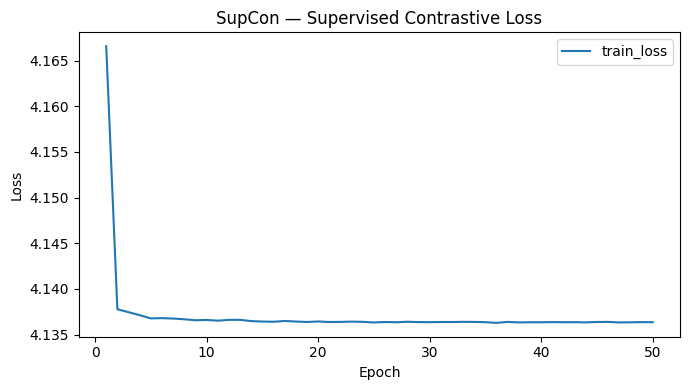

In [20]:
plot_history(supcon_history, title="SupCon — Supervised Contrastive Loss")

In [21]:
# extract SupCon embeddings — both h (backbone) and z (projection)

def extract_supcon_embeddings(model, dataloader, device):
    model.eval()
    all_h, all_z, all_labels = [], [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            h, z   = model(images)
            all_h.append(h.cpu())
            all_z.append(z.cpu())
            all_labels.append(labels.cpu())
    H = torch.cat(all_h,      dim=0)
    Z = torch.cat(all_z,      dim=0)
    y = torch.cat(all_labels, dim=0)
    return H, Z, y

H_supcon_train, Z_supcon_train, y_train = extract_supcon_embeddings(supcon_model, train_dl_eval, DEVICE)
H_supcon_val,   Z_supcon_val,   y_val   = extract_supcon_embeddings(supcon_model, val_dl_eval,   DEVICE)

H_supcon_train_l2 = l2_normalize_torch(H_supcon_train)
H_supcon_val_l2   = l2_normalize_torch(H_supcon_val)
Z_supcon_train_l2 = l2_normalize_torch(Z_supcon_train)
Z_supcon_val_l2   = l2_normalize_torch(Z_supcon_val)

print(f"SupCon h features: {H_supcon_train.shape}")
print(f"SupCon z features: {Z_supcon_train.shape}")

SupCon h features: torch.Size([1218, 512])
SupCon z features: torch.Size([1218, 128])


In [22]:
# linear probe comparison — h vs z, raw vs l2

print("SupCon — Linear Probe (CORROSION vs NOCORROSION)")
print("-" * 65)
sc_h_raw = run_linear_probe(H_supcon_train,    y_train, H_supcon_val,    y_val, "supcon_h_raw")
sc_h_l2  = run_linear_probe(H_supcon_train_l2, y_train, H_supcon_val_l2, y_val, "supcon_h_l2")
sc_z_raw = run_linear_probe(Z_supcon_train,    y_train, Z_supcon_val,    y_val, "supcon_z_raw")
sc_z_l2  = run_linear_probe(Z_supcon_train_l2, y_train, Z_supcon_val_l2, y_val, "supcon_z_l2")

SupCon — Linear Probe (CORROSION vs NOCORROSION)
-----------------------------------------------------------------
supcon_h_raw                        | train=0.9885 | val=0.9278
supcon_h_l2                         | train=0.8555 | val=0.8484
supcon_z_raw                        | train=0.7397 | val=0.7401
supcon_z_l2                         | train=0.7397 | val=0.7401


In [23]:
# kNN comparison

def run_knn(Z_train, y_train, Z_val, y_val, k_values=None, metric="cosine", label=""):
    if k_values is None:
        k_values = [1, 3, 5, 7, 11, 15]
    best_val, best_k = -1.0, -1
    for k in k_values:
        knn     = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(Z_train.numpy(), y_train.numpy())
        val_acc = accuracy_score(y_val.numpy(), knn.predict(Z_val.numpy()))
        if val_acc > best_val:
            best_val, best_k = val_acc, k
    print(f"{label:35s} | best_k={best_k} | val={best_val:.4f}")
    return best_val, best_k

print("SupCon — kNN (CORROSION vs NOCORROSION)")
print("-" * 65)
run_knn(H_supcon_train_l2, y_train, H_supcon_val_l2, y_val, label="supcon_h_l2 cosine",     metric="cosine")
run_knn(H_supcon_train,    y_train, H_supcon_val,    y_val, label="supcon_h_raw euclidean", metric="euclidean")
run_knn(Z_supcon_train_l2, y_train, Z_supcon_val_l2, y_val, label="supcon_z_l2 cosine",     metric="cosine")

SupCon — kNN (CORROSION vs NOCORROSION)
-----------------------------------------------------------------
supcon_h_l2 cosine                  | best_k=1 | val=0.8700
supcon_h_raw euclidean              | best_k=3 | val=0.8736
supcon_z_l2 cosine                  | best_k=1 | val=0.8303


(0.8303249097472925, 1)

In [24]:
# prototype classifier

def compute_class_prototypes(Z, y, num_classes):
    prototypes = []
    for c in range(num_classes):
        mask  = (y == c)
        proto = Z[mask].mean(dim=0)
        prototypes.append(proto)
    return torch.stack(prototypes, dim=0)

def predict_by_cosine(Z, prototypes):
    Z_norm = F.normalize(Z,          dim=1)
    P_norm = F.normalize(prototypes, dim=1)
    sim    = torch.mm(Z_norm, P_norm.T)
    return sim.argmax(dim=1)

def run_prototype(Z_train, y_train, Z_val, y_val, label=""):
    protos      = compute_class_prototypes(Z_train, y_train, num_classes=NUM_CLASSES)
    train_preds = predict_by_cosine(Z_train, protos)
    val_preds   = predict_by_cosine(Z_val,   protos)
    train_acc   = accuracy_score(y_train.numpy(), train_preds.numpy())
    val_acc     = accuracy_score(y_val.numpy(),   val_preds.numpy())
    print(f"{label:35s} | train={train_acc:.4f} | val={val_acc:.4f}")
    return val_acc

print("SupCon — Prototype Classifier (CORROSION vs NOCORROSION)")
print("-" * 65)
run_prototype(H_supcon_train_l2, y_train, H_supcon_val_l2, y_val, "supcon_h_l2")
run_prototype(Z_supcon_train_l2, y_train, Z_supcon_val_l2, y_val, "supcon_z_l2")

SupCon — Prototype Classifier (CORROSION vs NOCORROSION)
-----------------------------------------------------------------
supcon_h_l2                         | train=0.7980 | val=0.7762
supcon_z_l2                         | train=0.7406 | val=0.7401


0.740072202166065

### short interpretation

## Section 4 — Two-Stage Pipeline: SimCLR → SupCon

- SupCon encoder from the SimCLR pretrained backbone
- fine-tune with SupCon loss on labeled binary data

In [25]:
# initialise SupCon model from SimCLR backbone weights

supcon_2stage = ResNet18SupCon(proj_dim=SUPCON_PROJ_DIM).to(DEVICE)
supcon_2stage.encoder.load_state_dict(simclr_model.encoder.state_dict())

print("Loaded SimCLR backbone into SupCon model.")
print(f"Encoder params: {sum(p.numel() for p in supcon_2stage.encoder.parameters()):,}")

Loaded SimCLR backbone into SupCon model.
Encoder params: 11,176,512


In [26]:
# fine-tune with SupCon loss

supcon_2stage_criterion = SupConLoss(temperature=SUPCON_TEMP)
supcon_2stage_optimizer = torch.optim.Adam(supcon_2stage.parameters(), lr=SUPCON_LR)

supcon_2stage, supcon_2stage_history, supcon_2stage_best_loss = fit_supcon_model(
    supcon_2stage,
    train_dl_supcon,
    supcon_2stage_criterion,
    supcon_2stage_optimizer,
    DEVICE,
    epochs=SUPCON_EPOCHS,
    checkpoint_path="supcon_2stage_best.pt",
)

print(f"\nBest two-stage SupCon loss: {supcon_2stage_best_loss:.4f}")

Epoch 01/50 | loss=4.3267
Epoch 02/50 | loss=4.1431
Epoch 03/50 | loss=4.1405
Epoch 04/50 | loss=4.1397
Epoch 05/50 | loss=4.1387
Epoch 06/50 | loss=4.1382
Epoch 07/50 | loss=4.1378
Epoch 08/50 | loss=4.1376
Epoch 09/50 | loss=4.1376
Epoch 10/50 | loss=4.1375
Epoch 11/50 | loss=4.1371
Epoch 12/50 | loss=4.1369
Epoch 13/50 | loss=4.1370
Epoch 14/50 | loss=4.1369
Epoch 15/50 | loss=4.1369
Epoch 16/50 | loss=4.1368
Epoch 17/50 | loss=4.1370
Epoch 18/50 | loss=4.1368
Epoch 19/50 | loss=4.1367
Epoch 20/50 | loss=4.1368
Epoch 21/50 | loss=4.1368
Epoch 22/50 | loss=4.1366
Epoch 23/50 | loss=4.1366
Epoch 24/50 | loss=4.1365
Epoch 25/50 | loss=4.1366
Epoch 26/50 | loss=4.1366
Epoch 27/50 | loss=4.1367
Epoch 28/50 | loss=4.1365
Epoch 29/50 | loss=4.1365
Epoch 30/50 | loss=4.1366
Epoch 31/50 | loss=4.1364
Epoch 32/50 | loss=4.1366
Epoch 33/50 | loss=4.1364
Epoch 34/50 | loss=4.1364
Epoch 35/50 | loss=4.1365
Epoch 36/50 | loss=4.1365
Epoch 37/50 | loss=4.1364
Epoch 38/50 | loss=4.1364
Epoch 39/50 

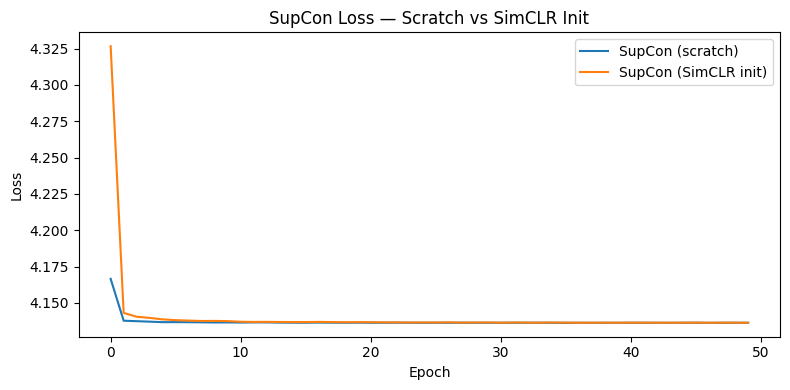

In [27]:
# compare training curves

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(supcon_history["train_loss"],        label="SupCon (scratch)")
ax.plot(supcon_2stage_history["train_loss"], label="SupCon (SimCLR init)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("SupCon Loss — Scratch vs SimCLR Init")
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
# extract two-stage features

H_2stage_train, Z_2stage_train, _ = extract_supcon_embeddings(supcon_2stage, train_dl_eval, DEVICE)
H_2stage_val,   Z_2stage_val,   _ = extract_supcon_embeddings(supcon_2stage, val_dl_eval,   DEVICE)

H_2stage_train_l2 = l2_normalize_torch(H_2stage_train)
H_2stage_val_l2   = l2_normalize_torch(H_2stage_val)

print("Two-stage features extracted.")

Two-stage features extracted.


In [29]:
# compare all three on linear probe

print("Linear Probe Comparison (CORROSION vs NOCORROSION)")
print("-" * 65)
run_linear_probe(H_simclr_train,    y_train, H_simclr_val,    y_val, "SimCLR only")
run_linear_probe(H_supcon_train_l2, y_train, H_supcon_val_l2, y_val, "SupCon (scratch)")
run_linear_probe(H_2stage_train_l2, y_train, H_2stage_val_l2, y_val, "SupCon (SimCLR init)")

Linear Probe Comparison (CORROSION vs NOCORROSION)
-----------------------------------------------------------------
SimCLR only                         | train=0.9893 | val=0.9242
SupCon (scratch)                    | train=0.8555 | val=0.8484
SupCon (SimCLR init)                | train=0.8793 | val=0.8953


(0.8793103448275862, 0.8953068592057761)

### short interpretation

## Section 5 — Final Comparison

In [30]:
# collect all results

results = []

feature_sets = {
    "SimCLR h_raw"          : (H_simclr_train,    H_simclr_val),
    "SimCLR h_l2"           : (H_simclr_train_l2, H_simclr_val_l2),
    "SupCon h_raw (scratch)": (H_supcon_train,     H_supcon_val),
    "SupCon h_l2 (scratch)" : (H_supcon_train_l2,  H_supcon_val_l2),
    "SupCon z_l2 (scratch)" : (Z_supcon_train_l2,  Z_supcon_val_l2),
    "SupCon h_l2 (2-stage)" : (H_2stage_train_l2,  H_2stage_val_l2),
}

for name, (Ztr, Zva) in feature_sets.items():
    clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf.fit(Ztr.numpy(), y_train.numpy())
    train_acc = accuracy_score(y_train.numpy(), clf.predict(Ztr.numpy()))
    val_acc   = accuracy_score(y_val.numpy(),   clf.predict(Zva.numpy()))
    results.append({
        "Method"   : name,
        "Train Acc": round(train_acc, 4),
        "Val Acc"  : round(val_acc,   4),
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("Val Acc", ascending=False)
    .reset_index(drop=True)
)

print(results_df.to_string(index=False))

                Method  Train Acc  Val Acc
           SimCLR h_l2     0.9220   0.9386
SupCon h_raw (scratch)     0.9885   0.9278
          SimCLR h_raw     0.9893   0.9242
 SupCon h_l2 (2-stage)     0.8793   0.8953
 SupCon h_l2 (scratch)     0.8555   0.8484
 SupCon z_l2 (scratch)     0.7397   0.7401


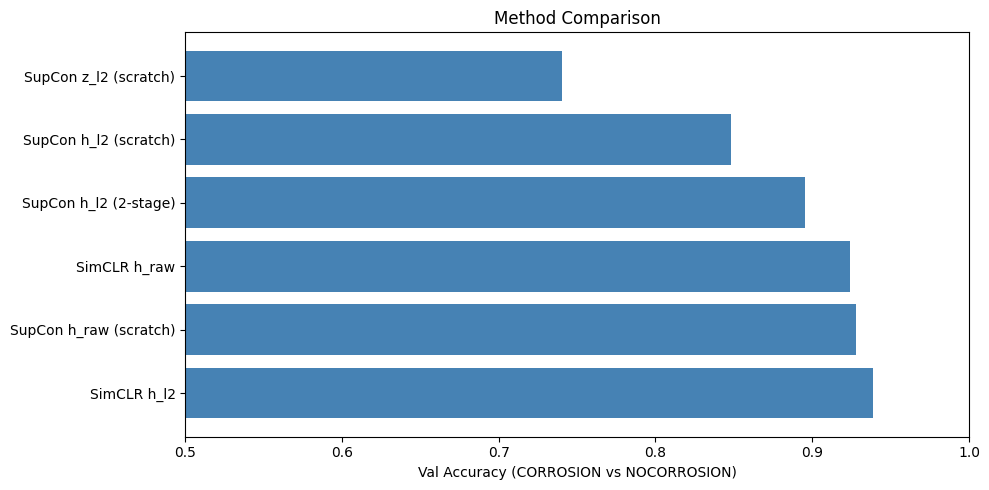

In [31]:
# bar chart

plt.figure(figsize=(10, 5))
plt.barh(results_df["Method"], results_df["Val Acc"], color="steelblue")
plt.xlabel("Val Accuracy (CORROSION vs NOCORROSION)")
plt.title("Method Comparison")
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

In [32]:
# save results

results_df.to_csv("simclr_supcon_results.csv", index=False)
torch.save({
    "simclr_history"        : simclr_history,
    "supcon_history"        : supcon_history,
    "supcon_2stage_history" : supcon_2stage_history,
    "results"               : results_df.to_dict(orient="records"),
}, "simclr_supcon_summary.pt")

print("Results saved.")

Results saved.


### short interpretation

## Section 6 — Rejection Thresholding on Unknown Surfaces

- use prototype cosine distance as a confidence score
- images too far from both prototypes are rejected as unknown
- evaluate on `unknown_val/` (MVTec textures: carpet, grid, hazelnut, leather, tile, wood)
- goal: high accuracy on accepted samples, high reject rate on unknowns

In [33]:
# extract features from unknown_val using best model

best_model = supcon_2stage

H_unknown, _, _ = extract_supcon_embeddings(best_model, unknown_dl, DEVICE)
H_unknown_l2    = l2_normalize_torch(H_unknown)

print(f"Unknown val features: {H_unknown_l2.shape}")

Unknown val features: torch.Size([173, 512])


In [34]:
# prototype-based rejection

def evaluate_rejection(Z_val, y_val, Z_unknown, protos, thresholds):
    Z_norm  = F.normalize(Z_val,     dim=1)
    U_norm  = F.normalize(Z_unknown, dim=1)
    P_norm  = F.normalize(protos,    dim=1)

    val_conf     = torch.mm(Z_norm, P_norm.T).max(dim=1).values
    unknown_conf = torch.mm(U_norm, P_norm.T).max(dim=1).values

    rows = []
    for thresh in thresholds:
        val_accepted     = val_conf     >= thresh
        unknown_rejected = unknown_conf <  thresh

        accepted_z     = F.normalize(Z_val[val_accepted], dim=1)
        preds          = torch.mm(accepted_z, P_norm.T).argmax(dim=1)
        true           = y_val[val_accepted]

        coverage     = val_accepted.float().mean().item()
        accepted_acc = accuracy_score(true.numpy(), preds.numpy()) if len(true) > 0 else 0.0
        reject_rate  = unknown_rejected.float().mean().item()

        rows.append({
            "Threshold"   : round(thresh,       2),
            "Coverage"    : round(coverage,      3),
            "Accepted Acc": round(accepted_acc,  4),
            "Reject Rate" : round(reject_rate,   3),
        })

    return pd.DataFrame(rows)

protos = compute_class_prototypes(H_2stage_train_l2, y_train, num_classes=NUM_CLASSES)

thresholds   = [i / 20 for i in range(5, 20)]
rejection_df = evaluate_rejection(H_2stage_val_l2, y_val, H_unknown_l2, protos, thresholds)
print(rejection_df.to_string(index=False))

 Threshold  Coverage  Accepted Acc  Reject Rate
      0.25     1.000        0.8628        0.000
      0.30     1.000        0.8628        0.000
      0.35     1.000        0.8628        0.000
      0.40     1.000        0.8628        0.000
      0.45     1.000        0.8628        0.000
      0.50     1.000        0.8628        0.000
      0.55     1.000        0.8628        0.040
      0.60     0.996        0.8623        0.069
      0.65     0.910        0.8571        0.220
      0.70     0.747        0.8454        0.601
      0.75     0.473        0.8321        0.769
      0.80     0.162        0.8222        0.780
      0.85     0.014        1.0000        0.942
      0.90     0.000        0.0000        1.000
      0.95     0.000        0.0000        1.000


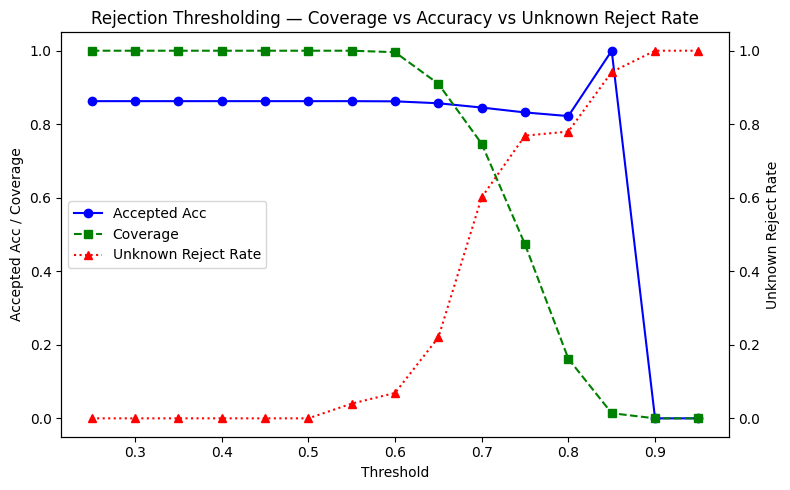

In [35]:
# coverage vs accuracy curve

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(rejection_df["Threshold"], rejection_df["Accepted Acc"], "b-o",  label="Accepted Acc")
ax1.plot(rejection_df["Threshold"], rejection_df["Coverage"],     "g--s", label="Coverage")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Accepted Acc / Coverage")

ax2 = ax1.twinx()
ax2.plot(rejection_df["Threshold"], rejection_df["Reject Rate"], "r:^", label="Unknown Reject Rate")
ax2.set_ylabel("Unknown Reject Rate")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left")

plt.title("Rejection Thresholding — Coverage vs Accuracy vs Unknown Reject Rate")
plt.tight_layout()
plt.show()

In [36]:
# find best operating point

perfect_rows = rejection_df[rejection_df["Accepted Acc"] == 1.0]
if not perfect_rows.empty:
    best_row = perfect_rows.sort_values("Coverage", ascending=False).iloc[0]
    print("Best threshold for 100% accepted accuracy:")
    print(best_row.to_string())
else:
    print("No threshold achieves 100% accepted accuracy.")
    print("Best accuracy row:")
    print(rejection_df.sort_values("Accepted Acc", ascending=False).iloc[0].to_string())

Best threshold for 100% accepted accuracy:
Threshold       0.850
Coverage        0.014
Accepted Acc    1.000
Reject Rate     0.942


### short interpretation
- higher threshold = more rejections = higher accepted accuracy but lower coverage
- the reject rate on unknown_val measures how well the model knows what it does not know
- ideal operating point: high coverage on known classes, high reject rate on unknown surfaces